<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula08c_kmeans_as_fs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


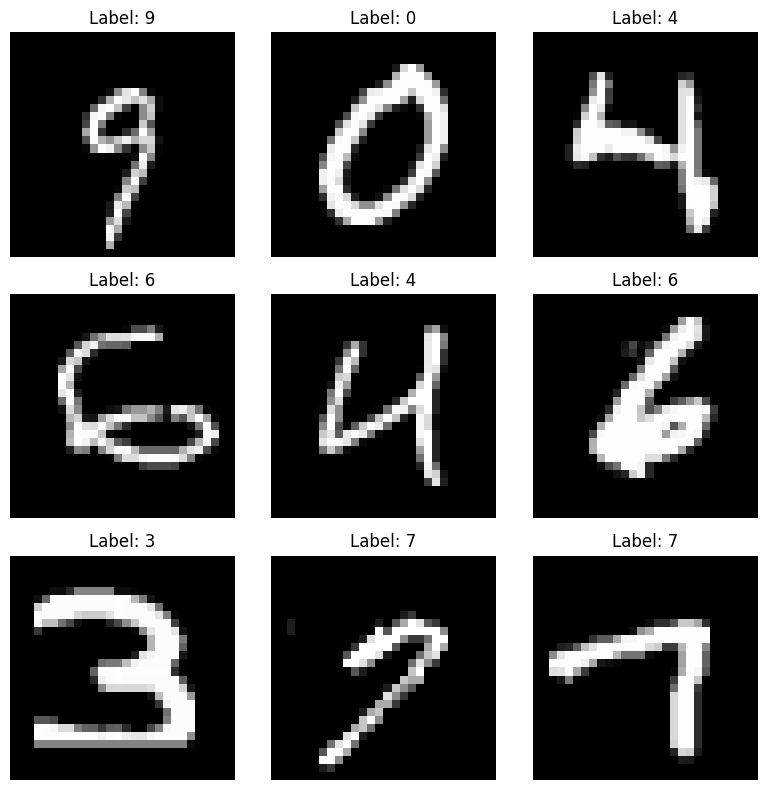

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Select 9 random indices
random_indices = np.random.choice(X_train.shape[0], 9, replace=False)

# Plot the images
plt.figure(figsize=(8, 8))
for i, idx in enumerate(random_indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [3]:
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)
print(X_train_flattened.shape)
print(X_test_flattened.shape)

(60000, 784)
(10000, 784)


In [4]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

scores = cross_val_score(RidgeClassifier(), X_train_flattened, y_train, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.8487833333333334,
[0.855      0.84158333 0.84125    0.8435     0.86258333]


In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

pipeline = make_pipeline(StandardScaler(), RidgeClassifier())
scores = cross_val_score(pipeline, X_train_flattened, y_train, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.8488166666666667,
[0.855      0.84158333 0.84125    0.8435     0.86275   ]


In [6]:
from sklearn.cluster import KMeans

model = make_pipeline(
    KMeans(n_clusters=200),
    RidgeClassifier()
)
scores = cross_val_score(model, X_train_flattened, y_train, cv=5)
print(f"Pipeline: {scores.mean()},\n{scores}")

Pipeline: 0.9324666666666668,
[0.934      0.932      0.92775    0.9265     0.94208333]


In [7]:
from sklearn.metrics import accuracy_score

In [8]:
ridge = RidgeClassifier()
ridge.fit(X_train_flattened, y_train)
y_pred_ridge = ridge.predict(X_test_flattened)
accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
print("Accuracy with Ridge Classifier:", accuracy_ridge)

Accuracy with Ridge Classifier: 0.8603


In [9]:
pipeline = make_pipeline(
    KMeans(n_clusters=250),
    RidgeClassifier()
)
pipeline.fit(X_train_flattened, y_train)
y_pred_pipeline = pipeline.predict(X_test_flattened)
accuracy_pipeline = accuracy_score(y_test, y_pred_pipeline)
print("Accuracy with Pipeline:", accuracy_pipeline)

Accuracy with Pipeline: 0.9403
